# Xanadu Spectral Methods Paper Experiments

## What This Notebook Checks

This notebook studies a probability distribution over bitstrings. The question is whether the spectral smoothness penalty from the Xanadu post/paper gives a more reasonable distribution than the empirical maximum-likelihood estimate.

The empirical distribution puts probability only on bitstrings that appeared in the data. That is often too sharp: two bitstrings that differ by only one bit can receive very different probabilities. The smoothness penalty discourages these jumps across one-bit Hamming neighbors. The expected effect is a distribution that sacrifices some raw likelihood but is less spiky.

The notebook has two experiments:

1. A small $n=3$ example where all $2^3=8$ states can be represented explicitly.
2. A larger $n=20$ example where the full state space has $2^{20}=1,048,576$ states, so the optimization is done on a sparse active set.

## Combined Objective Function

For a training multiset $\mathcal{X}$ of bitstrings $x \in \{0,1\}^n$, the smoothness energy is

$$
\mathcal{E}(p)
= \frac{1}{2^n}\sum_{x \in \{0,1\}^n}\sum_{i=1}^n
\left(p(x)-p(x\oplus e_i)\right)^2.
$$

Here $x \oplus e_i$ means flipping the $i$-th bit of $x$. The optimization problem is

$$
\begin{aligned}
\min_p \quad & -\left[\sum_{x \in \mathcal{X}}\log p(x) - \lambda \mathcal{E}(p)\right] \\
\text{s.t.}\quad & p(x) \ge 0, \\
& \sum_{x \in \{0,1\}^n}p(x)=1.
\end{aligned}
$$

Equivalently, using counts $c_x$ for the training multiset,

$$
f(p) = -\sum_{x \in \{0,1\}^n} c_x \log p_x + \lambda \mathcal{E}(p),
\qquad p \in \Delta_{2^n}.
$$

Lower values of $f(p)$ are better. The first term rewards fitting the observed data. The second term rewards smoothness across the hypercube.


## Concrete Problem Experiment

Use three-bit strings, so the probability vector has $2^3=8$ entries. The observed training multiset is summarized by the following counts:

$$
\begin{array}{c|cccccccc}
x & 000 & 001 & 010 & 011 & 100 & 101 & 110 & 111 \\
\hline
c_x & 10 & 6 & 5 & 0 & 5 & 0 & 0 & 2
\end{array}
$$

The unregularized empirical distribution assigns zero mass to the unobserved strings. The spectral smoothness term should instead spread some mass to Hamming-neighboring strings. We solve the constrained convex problem with the Frank-Wolfe algorithm on the simplex, starting from the simplest strictly positive state:

$$
p^{(0)}(x)=\frac{1}{8}\quad\text{for every }x\in\{0,1\}^3.
$$


### Setup for the Small Experiment

The next cell fixes the eight possible states, converts the observed counts into an empirical distribution, chooses $\lambda=200$, and starts Frank-Wolfe from the uniform distribution. It also prints the Python executable so that the saved run documents that the repository virtual environment was used.


In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np

print(sys.executable)
assert "/.venv/" in sys.executable or sys.executable.endswith("/.venv/bin/python")

n = 3
labels = [format(i, f"0{n}b") for i in range(2**n)]
counts_by_label = {"000": 10, "001": 6, "010": 5, "100": 5, "111": 2}
counts = np.array([counts_by_label.get(label, 0) for label in labels], dtype=float)
empirical = counts / counts.sum()
lam = 200.0
p0 = np.ones(2**n) / (2**n)

print(f"n = {n}, states = {len(labels)}, samples = {int(counts.sum())}, lambda = {lam:g}")
print(f"initial p min = {p0.min():.6f}, sum = {p0.sum():.6f}")


/home/lukas/Desktop/Gitrepos/LukasLatentSpace/.venv/bin/python
n = 3, states = 8, samples = 28, lambda = 200
initial p min = 0.125000, sum = 1.000000


### Optimization Method

For the small example we can store the full probability vector. The helper functions below compute the negative log-likelihood, the spectral smoothness energy, their gradients, and the combined objective.

Frank-Wolfe is a natural fit because the feasible set is the probability simplex. At each iteration, the linear minimization oracle chooses the state with the smallest gradient coordinate, then the current distribution is moved toward that state. The saved history records the combined objective, the smoothness energy, and the Frank-Wolfe gap, which is a convergence certificate.


In [2]:
def smoothness_energy(p, n):
    d = 2**n
    total = 0.0
    for x in range(d):
        for i in range(n):
            total += (p[x] - p[x ^ (1 << i)]) ** 2
    return total / d


def smoothness_gradient(p, n):
    d = 2**n
    grad = np.zeros_like(p)
    for x in range(d):
        for i in range(n):
            y = x ^ (1 << i)
            diff = p[x] - p[y]
            grad[x] += 2.0 * diff / d
            grad[y] -= 2.0 * diff / d
    return grad


def mle_objective(p, counts):
    observed = counts > 0
    return -float(np.dot(counts[observed], np.log(p[observed])))


def combined_objective(p, counts, n, lam):
    return mle_objective(p, counts) + lam * smoothness_energy(p, n)


def gradient(p, counts, n, lam):
    return -counts / p + lam * smoothness_gradient(p, n)


def simplex_lmo(grad):
    j = int(np.argmin(grad))
    s = np.zeros_like(grad)
    s[j] = 1.0
    return s, j


def frank_wolfe(counts, n, lam, p0, max_iter=1500, tol=1e-7):
    p = p0.astype(float).copy()
    history = []

    for t in range(1, max_iter + 1):
        grad = gradient(p, counts, n, lam)
        s, atom = simplex_lmo(grad)
        direction = s - p
        gap = float(np.dot(grad, p - s))
        energy = smoothness_energy(p, n)
        combined_value = mle_objective(p, counts) + lam * energy
        history.append({"iter": t, "combined_objective": combined_value, "smoothness_energy": energy, "gap": gap, "atom": atom, "gamma": 0.0})

        if gap <= tol:
            break

        gamma = 2.0 / (t + 2)
        p = p + gamma * direction
        history[-1]["gamma"] = gamma

    return p, history


In [3]:
p_fw, history = frank_wolfe(counts, n, lam, p0)

fw_mle = mle_objective(p_fw, counts)
fw_energy = smoothness_energy(p_fw, n)
fw_combined = fw_mle + lam * fw_energy

empirical_mle = mle_objective(empirical, counts)
empirical_energy = smoothness_energy(empirical, n)
empirical_combined = empirical_mle + lam * empirical_energy

print(f"iterations: {len(history)}")
print(f"final combined objective: {fw_combined:.9f}")
print(f"final Frank-Wolfe gap: {history[-1]['gap']:.3e}")
print(f"final MLE objective value: {fw_mle:.9f}")
print(f"final smoothness energy: {fw_energy:.9f}")
print(f"empirical combined objective: {empirical_combined:.9f}")
print(f"empirical MLE objective value: {empirical_mle:.9f}")
print(f"empirical smoothness energy: {empirical_energy:.9f}")
print(f"min p(x): {p_fw.min():.9f}, sum p(x): {p_fw.sum():.9f}")

print("\ncombined objective comparison")
print("distribution    combined objective    MLE objective    smoothness energy")
print(f"{'empirical':>12}  {empirical_combined:>18.6f}  {empirical_mle:>13.6f}  {empirical_energy:>17.6f}")
print(f"{'Frank-Wolfe':>12}  {fw_combined:>18.6f}  {fw_mle:>13.6f}  {fw_energy:>17.6f}")

print("\nstate  count  empirical   Frank-Wolfe")
for label, count, p_emp, p_hat in zip(labels, counts, empirical, p_fw):
    print(f"{label:>5}  {int(count):>5}  {p_emp:>9.6f}   {p_hat:>11.6f}")


iterations: 1500
final combined objective: 52.202066376
final Frank-Wolfe gap: 3.260e-01
final MLE objective value: 48.539491063
final smoothness energy: 0.018312877
empirical combined objective: 57.988522605
empirical MLE objective value: 42.044645054
empirical smoothness energy: 0.079719388
min p(x): 0.062523010, sum p(x): 1.000000000

combined objective comparison
distribution    combined objective    MLE objective    smoothness energy
   empirical           57.988523      42.044645           0.079719
 Frank-Wolfe           52.202066      48.539491           0.018313

state  count  empirical   Frank-Wolfe
  000     10   0.357143      0.235612
  001      6   0.214286      0.171460
  010      5   0.178571      0.158185
  011      0   0.000000      0.066880
  100      5   0.178571      0.157609
  101      0   0.000000      0.067482
  110      0   0.000000      0.062523
  111      2   0.071429      0.080249


### Result of the Small Experiment

The regularized Frank-Wolfe solution improves the combined objective from **57.99** for the empirical distribution to **52.20**. This happens even though the likelihood term alone becomes worse, from **42.04** to **48.54**, because the smoothness energy drops much more strongly, from **0.0797** to **0.0183**.

The important qualitative result is that the smoothness penalty assigns nonzero probability to strings that were never observed. In particular, `011`, `101`, and `110` all have count zero in the data, but the optimized distribution gives them about **6-7%** probability each. This is exactly the behavior expected from the penalty: nearby bitstrings should not be treated as completely impossible just because they did not appear in a small sample.

The final Frank-Wolfe gap is about **0.326**, so this should be read as an approximate solution rather than a fully converged optimum. The direction of the effect is nevertheless clear.


### How to Read the Small-Experiment Plots

The left plot compares the empirical distribution with the regularized Frank-Wolfe distribution. The middle plot shows the Frank-Wolfe gap over iterations. The right plot shows how the smoothness energy changes during optimization.


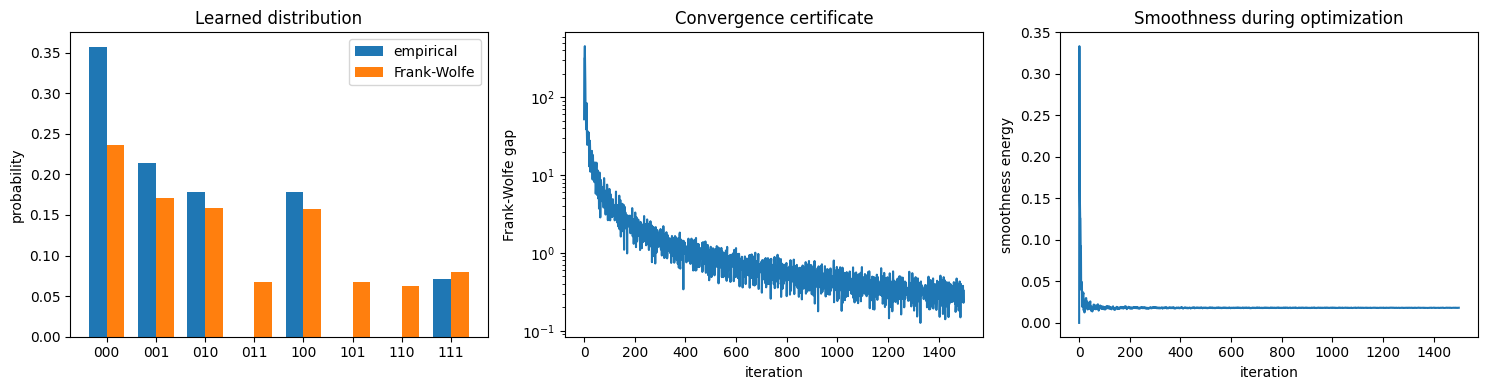

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
positions = np.arange(len(labels))

axes[0].bar(positions - 0.18, empirical, width=0.36, label="empirical")
axes[0].bar(positions + 0.18, p_fw, width=0.36, label="Frank-Wolfe")
axes[0].set_xticks(positions, labels)
axes[0].set_ylabel("probability")
axes[0].set_title("Learned distribution")
axes[0].legend()

axes[1].semilogy([item["gap"] for item in history])
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("Frank-Wolfe gap")
axes[1].set_title("Convergence certificate")

axes[2].plot([item["smoothness_energy"] for item in history])
axes[2].set_xlabel("iteration")
axes[2].set_ylabel("smoothness energy")
axes[2].set_title("Smoothness during optimization")

fig.tight_layout()


## Larger Sparse Experiment: $n = 20$

For $n=20$, the full probability vector has $2^{20}=1,048,576$ entries. Materializing and optimizing all entries is possible but not representative of the sparse method discussed in the post. Instead, the fully corrective variant keeps only an active support $S_t$.

At each outer iteration it forms a one-hop candidate set

$$
C_t = S_t \cup \{x \oplus e_i : x \in S_t,\ i=1,\ldots,n\},
$$

adds the best candidate according to the gradient, and then approximately re-optimizes the probabilities over the current active support. This is the purpose of the inner Frank-Wolfe loop.

The synthetic dataset below contains 90 samples generated around three 20-bit centers with small bit-flip noise. It has 55 distinct observed states. The main run uses $T=2$ outer iterations, $R=3000$ inner iterations, $\lambda=5\cdot 10^7$, and a pruning threshold of $10^{-12}$.

One implementation detail matters: the inner Frank-Wolfe step-size clock is now carried forward across outer iterations. That way, if the active support does not change, splitting a fixed number of correction steps across several outer iterations does not secretly change the optimization trajectory.


In [5]:
from collections import Counter

n_big = 20
d_big = 2**n_big
seed_big = 7
rng_big = np.random.default_rng(seed_big)

center_labels_big = [
    "00000000000000000000",
    "11110000111100001111",
    "10101010101010101010",
]
centers_big = [int(label, 2) for label in center_labels_big]


def hamming_noise_sample(center, n, flip_probability, rng):
    mask = 0
    for bit in range(n):
        if rng.random() < flip_probability:
            mask ^= 1 << bit
    return center ^ mask


samples_big = []
for center, sample_count, flip_probability in zip(
    centers_big,
    [30, 30, 30],
    [0.045, 0.055, 0.065],
):
    samples_big.extend(
        hamming_noise_sample(center, n_big, flip_probability, rng_big)
        for _ in range(sample_count)
    )

counts_big = Counter(samples_big)
observed_big = set(counts_big)
empirical_big = {x: count / len(samples_big) for x, count in counts_big.items()}

lam_big = 5e7
T_big = 2
R_big = 3_000
pruning_threshold_big = 1e-12

print(f"n = {n_big}, full states = {d_big:,}, samples = {len(samples_big)}")
print(f"random seed = {seed_big}")
print(f"observed states = {len(counts_big)}, lambda = {lam_big:.2e}")
print(f"outer iterations T = {T_big}, inner iterations R = {R_big}")
print(f"pruning threshold = {pruning_threshold_big:.1e}")
print("top observed states")
for x, count in counts_big.most_common(8):
    print(f"{format(x, f'0{n_big}b')}  count={count:2d}  empirical={empirical_big[x]:.4f}")


n = 20, full states = 1,048,576, samples = 90
random seed = 7
observed states = 55, lambda = 5.00e+07
outer iterations T = 2, inner iterations R = 3000
pruning threshold = 1.0e-12
top observed states
00000000000000000000  count=13  empirical=0.1444
10101010101010101010  count=10  empirical=0.1111
11110000111100001111  count= 9  empirical=0.1000
11110000111000001111  count= 3  empirical=0.0333
00000000000000000001  count= 2  empirical=0.0222
11110000111100000111  count= 2  empirical=0.0222
10101010101011101010  count= 2  empirical=0.0222
10101010101000101010  count= 2  empirical=0.0222


### Sparse Implementation Notes

The sparse implementation represents a distribution as a dictionary from integer-encoded bitstrings to probabilities. This avoids storing the full $2^{20}$ vector.

The smoothness energy and gradient are computed only for edges touching the current support. The candidate set consists of the active states plus their one-bit neighbors. After each outer step, the inner Frank-Wolfe loop corrects the probability weights on the active support, and pruning removes numerically negligible unobserved atoms while always retaining observed states so the likelihood remains finite.

The important distinction is that $T$ and $R$ control different parts of the algorithm. $T$ is a support-discovery budget: each outer step can add at most one new bitstring. $R$ is a correction budget: it determines how accurately the probabilities are rebalanced on the currently selected support.

We noticed the step-size issue by varying $T$ and $R$ in the larger experiment. Some settings changed the objective and final probabilities even though the active support did not change. That made the expected invariance clear: if the support stays fixed, then $T=x, R=y$ should behave like $T=1, R=xy$, because both runs are just doing the same amount of restricted optimization on the same simplex.

The previous implementation violated this because the inner schedule

$$
\gamma_r = \frac{2}{2+r}
$$

was restarted at $r=1$ after every outer iteration. That meant an unchanged-support outer iteration did not simply continue the correction from the previous iteration; it repeated the beginning of the same optimization with another large $2/3$ step. This made $T$ a hidden restart parameter, which is less favorable than just continuing the restricted optimization when no new support has been found.

The code below therefore keeps a running inner step counter by default. Passing `continue_inner_clock=False` recovers the old restart behavior for comparison, but the main experiment uses the continuous clock so that $T$ remains primarily a support-discovery parameter.

The tie-breaking rule uses the integer state id, which makes the run deterministic for a fixed random seed.


In [6]:
neighbor_cache = {}


def sparse_neighbors(x, n):
    key = (n, x)
    neighbors = neighbor_cache.get(key)
    if neighbors is None:
        neighbors = [x ^ (1 << bit) for bit in range(n)]
        neighbor_cache[key] = neighbors
    return neighbors


def sparse_smoothness_energy(p, n):
    d = 2**n
    seen_edges = set()
    total = 0.0

    for x, px in p.items():
        if px == 0.0:
            continue
        for y in sparse_neighbors(x, n):
            edge = (x, y) if x < y else (y, x)
            if edge in seen_edges:
                continue
            seen_edges.add(edge)
            diff = px - p.get(y, 0.0)
            total += diff * diff

    return 2.0 * total / d


def sparse_mle_objective(p, counts):
    total = 0.0
    for x, count in counts.items():
        px = p.get(x, 0.0)
        if px <= 0.0:
            return float("inf")
        total -= count * np.log(px)
    return float(total)


def sparse_combined_objective(p, counts, n, lam):
    return sparse_mle_objective(p, counts) + lam * sparse_smoothness_energy(p, n)


def sparse_smoothness_gradient_coordinate(x, p, n):
    px = p.get(x, 0.0)
    neighbor_sum = 0.0
    for y in sparse_neighbors(x, n):
        neighbor_sum += px - p.get(y, 0.0)
    return 4.0 * neighbor_sum / (2**n)


def sparse_gradient_coordinate(x, p, counts, n, lam):
    px = p.get(x, 0.0)
    count = counts.get(x, 0)

    if count > 0:
        if px <= 0.0:
            return -float("inf")
        mle_grad = -count / px
    else:
        mle_grad = 0.0

    return mle_grad + lam * sparse_smoothness_gradient_coordinate(x, p, n)


def sparse_candidate_set(active_set, n):
    candidates = set(active_set)
    for x in active_set:
        candidates.update(sparse_neighbors(x, n))
    return candidates


def stable_argmin(gradients):
    return min(gradients, key=lambda x: (gradients[x], x))


def prune_support(p, active_set, observed_set, threshold):
    kept = {
        x: px
        for x, px in p.items()
        if x in observed_set or px > threshold
    }
    removed_mass = sum(px for x, px in p.items() if x not in kept)

    if removed_mass > 0.0:
        normalization = sum(kept.values())
        kept = {x: px / normalization for x, px in kept.items()}

    pruned_active = (set(active_set) & set(kept)) | set(observed_set)
    pruned_atoms = len(set(active_set) - pruned_active)
    return kept, pruned_active, pruned_atoms, removed_mass


def restricted_frank_wolfe(
    p,
    active_set,
    counts,
    n,
    lam,
    inner_iterations,
    start_r=1,
    tol=1e-8,
):
    active = set(active_set)
    last_gap = float("nan")
    last_atom = None
    steps_taken = 0

    for offset in range(inner_iterations):
        r = start_r + offset
        gradients = {x: sparse_gradient_coordinate(x, p, counts, n, lam) for x in active}
        last_atom = stable_argmin(gradients)
        average_gradient = sum(p.get(x, 0.0) * gradients[x] for x in active)
        last_gap = average_gradient - gradients[last_atom]
        if last_gap <= tol:
            break

        direction = {x: -px for x, px in p.items() if x in active}
        direction[last_atom] = direction.get(last_atom, 0.0) + 1.0
        gamma = 2.0 / (2.0 + r)

        keys = set(p) | set(direction)
        p = {
            x: p.get(x, 0.0) + gamma * direction.get(x, 0.0)
            for x in keys
            if p.get(x, 0.0) + gamma * direction.get(x, 0.0) > 0.0
        }
        steps_taken += 1

    return p, last_gap, last_atom, steps_taken


def fully_corrective_frank_wolfe(
    counts,
    n,
    lam,
    outer_iterations,
    inner_iterations,
    pruning_threshold=0.0,
    continue_inner_clock=True,
):
    sample_count = sum(counts.values())
    observed = set(counts)
    active = set(observed)
    p = {x: count / sample_count for x, count in counts.items()}
    history = []
    next_inner_r = 1

    for t in range(1, outer_iterations + 1):
        candidates = sparse_candidate_set(active, n)
        outer_gradients = {
            x: sparse_gradient_coordinate(x, p, counts, n, lam)
            for x in candidates
        }
        new_atom = stable_argmin(outer_gradients)
        was_new = new_atom not in active
        active.add(new_atom)

        inner_start_r = next_inner_r if continue_inner_clock else 1
        p, inner_gap, inner_atom, inner_steps_taken = restricted_frank_wolfe(
            p,
            active,
            counts,
            n,
            lam,
            inner_iterations,
            start_r=inner_start_r,
        )
        if continue_inner_clock:
            next_inner_r += inner_steps_taken

        active_size_before_pruning = len(active)

        # Pruning is part of the outer FW loop: first correct on the current support,
        # then remove inactive atoms before the next support-discovery step.
        p, active, pruned_atoms, pruned_mass = prune_support(
            p, active, observed, pruning_threshold
        )
        active_size_after_pruning = len(active)

        certificate_candidates = sparse_candidate_set(active, n)
        certificate_gradients = {
            x: sparse_gradient_coordinate(x, p, counts, n, lam)
            for x in certificate_candidates
        }
        average_gradient = sum(
            p.get(x, 0.0) * sparse_gradient_coordinate(x, p, counts, n, lam)
            for x in active
        )
        candidate_gap = average_gradient - min(certificate_gradients.values())

        history.append({
            "outer_iter": t,
            "combined_objective": sparse_combined_objective(p, counts, n, lam),
            "smoothness_energy": sparse_smoothness_energy(p, n),
            "candidate_gap": candidate_gap,
            "inner_gap": inner_gap,
            "inner_start_r": inner_start_r,
            "inner_steps_taken": inner_steps_taken,
            "active_size_before_pruning": active_size_before_pruning,
            "active_size_after_pruning": active_size_after_pruning,
            "active_size": active_size_after_pruning,
            "positive_support": sum(px > 1e-12 for px in p.values()),
            "unobserved_mass": sum(px for x, px in p.items() if x not in observed),
            "pruned_atoms": pruned_atoms,
            "pruned_mass": pruned_mass,
            "new_atom": new_atom,
            "was_new": was_new,
            "inner_atom": inner_atom,
        })

    return p, active, history


def distribution_distance(left, right):
    keys = set(left) | set(right)
    distances = [abs(left.get(x, 0.0) - right.get(x, 0.0)) for x in keys]
    return sum(distances), max(distances, default=0.0)


def support_unchanged(history, observed_size):
    return all(
        (not item["was_new"])
        and item["active_size_before_pruning"] == observed_size
        and item["active_size_after_pruning"] == observed_size
        for item in history
    )


def compare_support_equivalence(
    counts,
    n,
    lam,
    outer_iterations,
    inner_iterations,
    pruning_threshold,
    continue_inner_clock,
):
    left_p, left_active, left_history = fully_corrective_frank_wolfe(
        counts,
        n,
        lam,
        outer_iterations,
        inner_iterations,
        pruning_threshold=pruning_threshold,
        continue_inner_clock=continue_inner_clock,
    )
    right_p, right_active, right_history = fully_corrective_frank_wolfe(
        counts,
        n,
        lam,
        1,
        outer_iterations * inner_iterations,
        pruning_threshold=pruning_threshold,
        continue_inner_clock=continue_inner_clock,
    )
    l1_distance, max_abs_distance = distribution_distance(left_p, right_p)
    observed_size = len(counts)

    return {
        "T": outer_iterations,
        "R": inner_iterations,
        "total_inner": outer_iterations * inner_iterations,
        "support_unchanged": support_unchanged(left_history, observed_size)
        and support_unchanged(right_history, observed_size),
        "same_active": left_active == right_active,
        "objective_left": sparse_combined_objective(left_p, counts, n, lam),
        "objective_right": sparse_combined_objective(right_p, counts, n, lam),
        "objective_delta": sparse_combined_objective(left_p, counts, n, lam)
        - sparse_combined_objective(right_p, counts, n, lam),
        "l1_distance": l1_distance,
        "max_abs_distance": max_abs_distance,
    }


def print_equivalence_table(title, rows):
    print(f"\n{title}")
    print(
        "T    R    T*R   unchanged  same_active  "
        "objective(T,R)  objective(1,T*R)  delta       L1_dist    max_abs"
    )
    for row in rows:
        print(
            f"{row['T']:>3}  "
            f"{row['R']:>3}  "
            f"{row['total_inner']:>5}  "
            f"{str(row['support_unchanged']):>9}  "
            f"{str(row['same_active']):>11}  "
            f"{row['objective_left']:>14.6f}  "
            f"{row['objective_right']:>17.6f}  "
            f"{row['objective_delta']:>10.6f}  "
            f"{row['l1_distance']:>9.6f}  "
            f"{row['max_abs_distance']:>8.6f}"
        )


In [7]:
p_fc, active_fc, history_fc = fully_corrective_frank_wolfe(
    counts_big,
    n_big,
    lam_big,
    T_big,
    R_big,
    pruning_threshold=pruning_threshold_big,
    continue_inner_clock=True,
)

empirical_objective_big = sparse_combined_objective(
    empirical_big, counts_big, n_big, lam_big
)
fc_objective_big = sparse_combined_objective(p_fc, counts_big, n_big, lam_big)
final_history = history_fc[-1]

print("inner step-size clock: continuous")
print(f"initial empirical objective: {empirical_objective_big:.6f}")
print(f"final fully corrective objective: {fc_objective_big:.6f}")
print(f"final candidate-set FW gap: {final_history['candidate_gap']:.3e}")
print(f"active set size: {len(active_fc)}")
print(f"positive support: {final_history['positive_support']}")
print(f"mass on unobserved states: {final_history['unobserved_mass']:.6f}")
print(f"total pruned atoms: {sum(item['pruned_atoms'] for item in history_fc)}")
print(f"total pruned mass: {sum(item['pruned_mass'] for item in history_fc):.3e}")
print(f"probability sum: {sum(p_fc.values()):.12f}")
print(f"minimum positive p: {min(p_fc.values()):.3e}")

print("\nouter iteration summary")
print("iter  new?  active  support  unobs_mass  inner_start  steps  candidate_gap  objective")
for item in history_fc:
    print(
        f"{item['outer_iter']:>4}  "
        f"{str(item['was_new']):>5}  "
        f"{item['active_size_after_pruning']:>6}  "
        f"{item['positive_support']:>7}  "
        f"{item['unobserved_mass']:>10.6f}  "
        f"{item['inner_start_r']:>11}  "
        f"{item['inner_steps_taken']:>5}  "
        f"{item['candidate_gap']:>13.3e}  "
        f"{item['combined_objective']:>9.6f}"
    )

print("\nobserved states sorted by count")
print("state                 count  empirical  fully corrective")
observed_rows = sorted(
    counts_big.items(),
    key=lambda item: (-item[1], item[0]),
)
for x, count in observed_rows[:12]:
    print(
        f"{format(x, f'0{n_big}b')}  "
        f"{count:>5}  "
        f"{empirical_big[x]:>9.6f}  "
        f"{p_fc.get(x, 0.0):>16.6f}"
    )


inner step-size clock: continuous
initial empirical objective: 410.560381
final fully corrective objective: 368.400951
final candidate-set FW gap: 1.896e+00
active set size: 56
positive support: 56
mass on unobserved states: 0.000634
total pruned atoms: 0
total pruned mass: 0.000e+00
probability sum: 1.000000000000
minimum positive p: 6.337e-04

outer iteration summary
iter  new?  active  support  unobs_mass  inner_start  steps  candidate_gap  objective
   1  False      55       55    0.000000            1   3000      3.616e+00  368.409912
   2   True      56       56    0.000634         3001   3000      1.896e+00  368.400951

observed states sorted by count
state                 count  empirical  fully corrective
00000000000000000000     13   0.144444          0.061263
10101010101010101010     10   0.111111          0.052823
11110000111100001111      9   0.100000          0.050661
11110000111000001111      3   0.033333          0.027369
00000000000000000001      2   0.022222          

### Support-Equivalence Check

This is the diagnostic that exposed the step-size issue. We first changed $T$ and $R$ and observed that the result could move even when the support set did not. That led to the realization that, with unchanged support, the algorithm should not restart the same restricted optimization it had already begun in the previous outer iteration. It should continue that optimization.

The check below compares runs with $T=x, R=y$ against runs with $T=1, R=xy$ on the same $n=20$ data. In the shown cases the support condition is satisfied: the active support does not change and the final active sets match.

With the old reset behavior, the two factorizations still produced different distributions. The only difference was that the inner Frank-Wolfe schedule restarted at each outer loop, so $T$ changed the correction dynamics even though it did not change the support.

With the continuous inner clock, the same unchanged-support tests agree to numerical precision. This is the more favorable behavior: when support discovery is idle, the algorithm spends the next correction budget continuing the current restricted optimization rather than repeating its early large-step phase.


In [8]:
reset_rows = [
    compare_support_equivalence(
        counts_big,
        n_big,
        lam_big,
        t,
        r,
        pruning_threshold_big,
        continue_inner_clock=False,
    )
    for t, r in [(8, 40), (5, 60), (120, 300)]
]
continuous_rows = [
    compare_support_equivalence(
        counts_big,
        n_big,
        lam_big,
        t,
        r,
        pruning_threshold_big,
        continue_inner_clock=True,
    )
    for t, r in [(8, 40), (5, 60)]
]

print_equivalence_table("Old behavior: inner clock resets each outer loop", reset_rows)
print_equivalence_table("Updated behavior: continuous inner clock", continuous_rows)



Old behavior: inner clock resets each outer loop
T    R    T*R   unchanged  same_active  objective(T,R)  objective(1,T*R)  delta       L1_dist    max_abs
  8   40    320       True         True      497.124816         369.330980  127.793836   0.854228  0.038555
  5   60    300       True         True      395.597913         369.073994   26.523919   0.520803  0.027287
120  300  36000       True         True      369.311745         368.400896    0.910848   0.096201  0.003748

Updated behavior: continuous inner clock
T    R    T*R   unchanged  same_active  objective(T,R)  objective(1,T*R)  delta       L1_dist    max_abs
  8   40    320       True         True      369.330980         369.330980    0.000000   0.000000  0.000000
  5   60    300       True         True      369.073994         369.073994    0.000000   0.000000  0.000000


### Result of the Larger Experiment

With $T=2$ and $R=3000$, the fully corrective sparse run lowers the combined objective from **410.56** for the empirical distribution to **368.40**. The probability mass remains normalized, and all retained probabilities are positive.

The final support is still almost the empirical support: it contains **56** states, compared with **55** observed states. Only about **0.000634** probability mass lies on unobserved states. The first outer step selected an already observed state, and the second outer step added one new neighboring state with very small mass. This supports the practical conclusion from the parameter search: increasing $T$ is not the main bottleneck here, because support discovery saturates quickly.

The main effect is reweighting. The three most frequent centers are compressed substantially: empirical probabilities **0.144**, **0.111**, and **0.100** become approximately **0.061**, **0.053**, and **0.051**. Several singleton states move upward from **0.011** to roughly **0.016**. This is smoothing of the empirical distribution: the result is less concentrated on the most frequent samples, while the active support remains almost unchanged.

The final candidate-set Frank-Wolfe gap is about **1.90**. This is a certificate only relative to the one-hop candidate set, not the full hypercube, but it is much smaller than in the previous lower-$R$ run. The larger inner correction budget therefore does what we want in this setting: it better optimizes the weights on the support that the outer loop has already found.


### How to Read the Larger-Experiment Plots

The upper-left plot tracks the combined objective and compares it with the empirical baseline. The upper-right plot shows the candidate-set Frank-Wolfe gap. The lower-left plot tracks the active support before and after pruning, together with the number of positive-probability states; with $T=2$, this plot is intentionally short and shows that the support barely changes. The lower-right plot shows the largest probabilities in the learned sparse distribution.


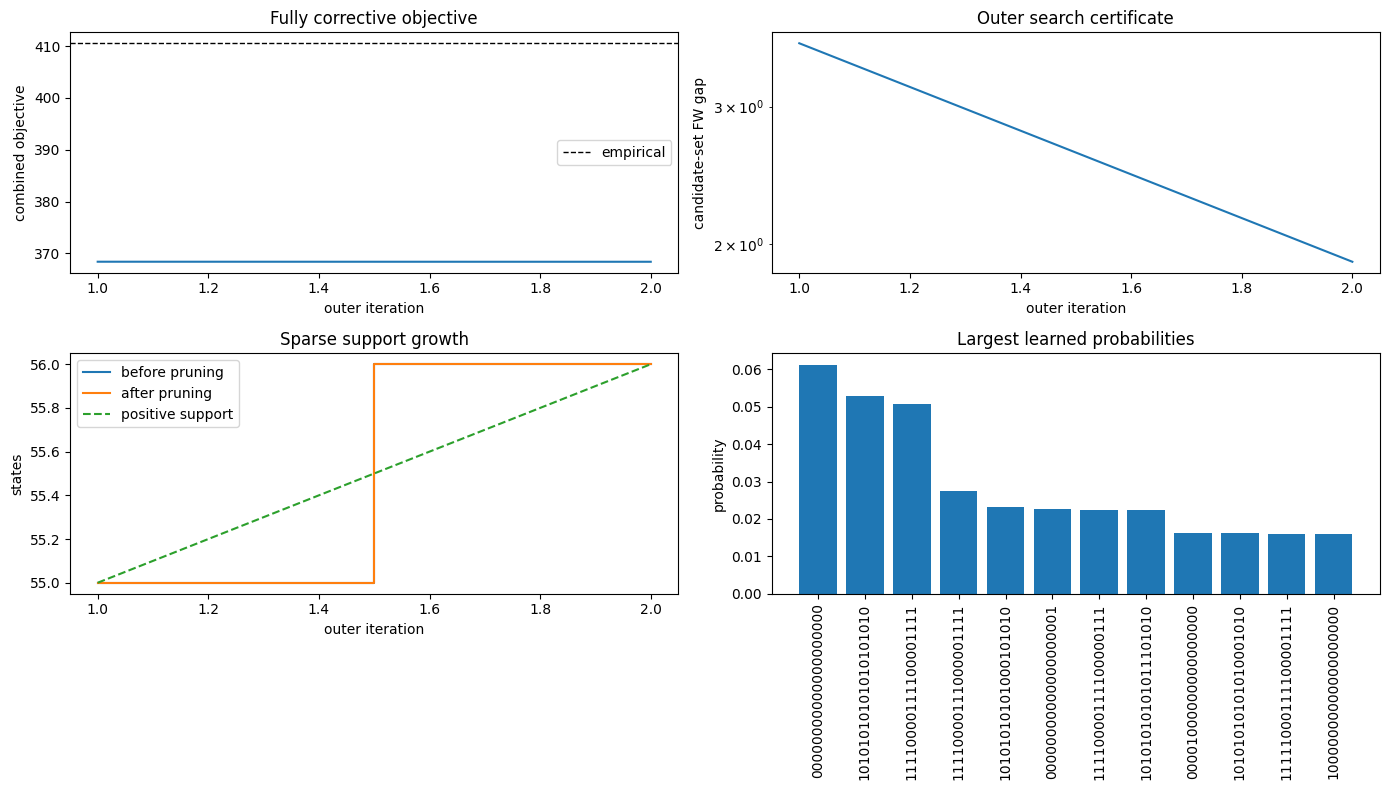

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
iterations_fc = [item["outer_iter"] for item in history_fc]

axes[0, 0].plot(iterations_fc, [item["combined_objective"] for item in history_fc])
axes[0, 0].axhline(empirical_objective_big, color="black", linestyle="--", linewidth=1, label="empirical")
axes[0, 0].set_xlabel("outer iteration")
axes[0, 0].set_ylabel("combined objective")
axes[0, 0].set_title("Fully corrective objective")
axes[0, 0].legend()

axes[0, 1].semilogy(iterations_fc, [item["candidate_gap"] for item in history_fc])
axes[0, 1].set_xlabel("outer iteration")
axes[0, 1].set_ylabel("candidate-set FW gap")
axes[0, 1].set_title("Outer search certificate")

pre_prune_sizes = [item["active_size_before_pruning"] for item in history_fc]
post_prune_sizes = [item["active_size_after_pruning"] for item in history_fc]
axes[1, 0].step(iterations_fc, pre_prune_sizes, where="mid", label="before pruning")
axes[1, 0].step(iterations_fc, post_prune_sizes, where="mid", label="after pruning")
axes[1, 0].plot(iterations_fc, [item["positive_support"] for item in history_fc], linestyle="--", label="positive support")
for iteration, before, after in zip(iterations_fc, pre_prune_sizes, post_prune_sizes):
    if before > after:
        axes[1, 0].vlines(iteration, after, before, color="tab:red", linewidth=2)
axes[1, 0].set_xlabel("outer iteration")
axes[1, 0].set_ylabel("states")
axes[1, 0].set_title("Sparse support growth")
axes[1, 0].legend()

top_states_fc = sorted(p_fc, key=p_fc.get, reverse=True)[:12]
top_labels_fc = [format(x, f"0{n_big}b") for x in top_states_fc]
top_values_fc = [p_fc[x] for x in top_states_fc]
bar_positions_fc = np.arange(len(top_states_fc))
axes[1, 1].bar(bar_positions_fc, top_values_fc)
axes[1, 1].set_xticks(bar_positions_fc, top_labels_fc, rotation=90)
axes[1, 1].set_ylabel("probability")
axes[1, 1].set_title("Largest learned probabilities")

fig.tight_layout()


## Overall Takeaway

The experiments confirm the intended role of the spectral smoothness term. It trades some likelihood on the observed sample for a distribution that varies less sharply across neighboring bitstrings.

In the small $n=3$ problem, this produces the clearest support-expansion effect: previously unseen neighboring states receive nonzero probability. In the larger $n=20$ sparse run, the support barely expands. The current best interpretation is that the regularizer mostly smooths the empirical distribution by rebalancing probability mass among observed states, rather than by adding many new states.

The additional support-equivalence check clarifies an implementation point that came from varying $T$ and $R$. When support does not change, another outer iteration should not restart the same restricted optimization. It should continue it. Restarting the inner Frank-Wolfe step-size schedule at every outer iteration is a real restart heuristic; it can change the result even when the support set does not change. The notebook now keeps the inner clock continuous by default, so unchanged-support runs with the same total number of correction steps agree.

That is why the larger experiment uses a small outer budget and a large inner budget. $T=2$ is enough to verify that support discovery does not materially change the solution, while $R=3000$ gives the fully corrective step enough room to converge on the almost fixed support. The remaining Frank-Wolfe gaps should still be read as candidate-set certificates rather than global convergence guarantees.
